In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.gradient import simple_gradient, gradient
from src.prediction import predict_
from src.fit import fit_

In [2]:
x = np.array([12.4956442, 21.5007972, 31.5527382, 48.9145838, 57.5088733]).reshape(
    (-1, 1)
)
y = np.array([37.4013816, 36.1473236, 45.7655287, 46.6793434, 59.5585554]).reshape(
    (-1, 1)
)
theta1 = np.array([2, 0.7]).reshape((-1, 1))
result = simple_gradient(x, y, theta1)

assert np.allclose(result, np.array([[-19.0342574], [-586.66875564]]))
theta2 = np.array([1, -0.4]).reshape((-1, 1))
result = simple_gradient(x, y, theta2)

assert np.allclose(result, np.array([[-57.86823748], [-2230.12297889]]))

In [3]:
x = np.array([12.4956442, 21.5007972, 31.5527382, 48.9145838, 57.5088733]).reshape(
    (-1, 1)
)
y = np.array([37.4013816, 36.1473236, 45.7655287, 46.6793434, 59.5585554]).reshape(
    (-1, 1)
)
theta1 = np.array([2, 0.7]).reshape((-1, 1))
result = gradient(x, y, theta1)

assert np.allclose(result, np.array([[-19.0342], [-586.6687]]), atol=1e-4)
theta2 = np.array([1, -0.4]).reshape((-1, 1))
result = gradient(x, y, theta2)

assert np.allclose(result, np.array([[-57.8682], [-2230.1229]]), atol=1e-4)

In [4]:
x = np.array([[12.4956442], [21.5007972], [31.5527382], [48.9145838], [57.5088733]])
y = np.array([[37.4013816], [36.1473236], [45.7655287], [46.6793434], [59.5585554]])
theta = np.array([1, 1]).reshape((-1, 1))
theta1 = fit_(x, y, theta, alpha=5e-8, max_iter=1500000)

assert np.allclose(theta1, np.array([[1.40709365], [1.1150909]]), atol=1e-7)
prediction = predict_(x, theta1)

assert np.allclose(
    prediction,
    np.array(
        [[15.3408728], [25.38243697], [36.59126492], [55.95130097], [65.53471499]]
    ),
    atol=1e-7,
)

In [5]:
from src.linear_regression import MyLinearRegression as MyLR

In [6]:
x = np.array([[12.4956442], [21.5007972], [31.5527382], [48.9145838], [57.5088733]])
y = np.array([[37.4013816], [36.1473236], [45.7655287], [46.6793434], [59.5585554]])
lr1 = MyLR(np.array([[2], [0.7]]))
y_hat = lr1.predict_(x)
assert np.allclose(
    y_hat,
    np.array(
        [[10.74695094], [17.05055804], [24.08691674], [36.24020866], [42.25621131]]
    ),
    atol=1e-7,
)
loss_elements = lr1.loss_elem_(y, y_hat)
assert np.allclose(
    loss_elements,
    np.array(
        [[710.45867381], [364.68645485], [469.96221651], [108.97553412], [299.37111101]]
    ),
    atol=1e-7,
)
loss_value = lr1.loss_(y, y_hat)
assert np.isclose(loss_value, 195.34539903032385)
lr2 = MyLR(np.array([[1], [1]]), 5e-8, 1500000)
lr2.fit_(x, y)
assert np.allclose(lr2.thetas, np.array([[1.40709365], [1.1150909]]), atol=1e-7)
predictions = lr2.predict_(x)
assert np.allclose(
    predictions,
    np.array(
        [[15.3408728], [25.38243697], [36.59126492], [55.95130097], [65.53471499]]
    ),
    atol=1e-7,
)
y_hat2 = lr2.predict_(x)
loss_elements_2 = lr2.loss_elem_(y, y_hat2)
assert np.allclose(
    loss_elements_2,
    np.array(
        [[486.66604863], [115.88278416], [84.16711596], [85.96919719], [35.71448348]]
    ),
    atol=1e-7,
)
loss_value_2 = lr2.loss_(y, y_hat2)
assert np.isclose(loss_value_2, 80.83996294128525)

[[89.12156266]
 [-9.00900799]]
[-29.00900799 -28.60496759 -28.20092718 -27.79688678 -27.39284638
 -26.98880597 -26.58476557 -26.18072516 -25.77668476 -25.37264436
 -24.96860395 -24.56456355 -24.16052314 -23.75648274 -23.35244234
 -22.94840193 -22.54436153 -22.14032112 -21.73628072 -21.33224032
 -20.92819991 -20.52415951 -20.1201191  -19.7160787  -19.3120383
 -18.90799789 -18.50395749 -18.09991708 -17.69587668 -17.29183627
 -16.88779587 -16.48375547 -16.07971506 -15.67567466 -15.27163425
 -14.86759385 -14.46355345 -14.05951304 -13.65547264 -13.25143223
 -12.84739183 -12.44335143 -12.03931102 -11.63527062 -11.23123021
 -10.82718981 -10.42314941 -10.019109    -9.6150686   -9.21102819
  -8.80698779  -8.40294739  -7.99890698  -7.59486658  -7.19082617
  -6.78678577  -6.38274537  -5.97870496  -5.57466456  -5.17062415
  -4.76658375  -4.36254335  -3.95850294  -3.55446254  -3.15042213
  -2.74638173  -2.34234133  -1.93830092  -1.53426052  -1.13022011
  -0.72617971  -0.32213931   0.0819011    0.48

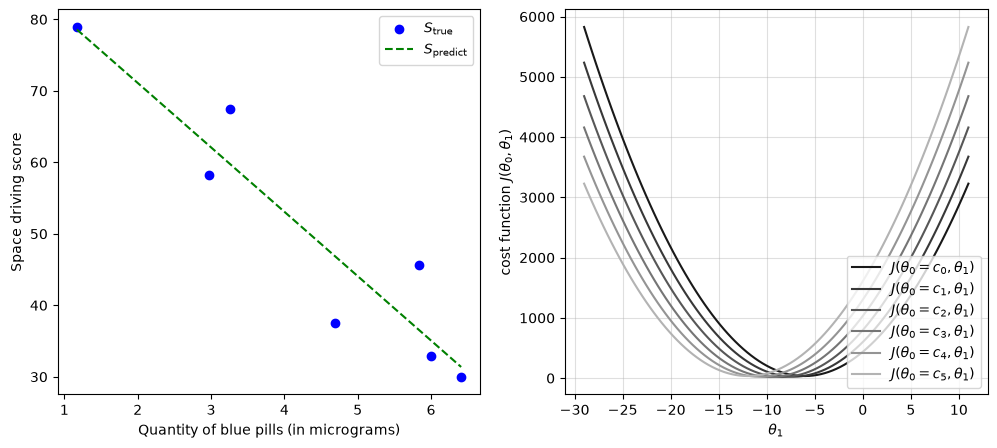

In [10]:
df = pd.read_csv("../attachments/are_blue_pills_magics.csv")
Xpills = df["Micrograms"].values.reshape(-1, 1)
Yscore = df["Score"].values.reshape(-1, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(Xpills, Yscore, label=f"$S_{{\\text{{true}}}}$", color="blue")
ax1.set_xlabel("Quantity of blue pills (in micrograms)")
ax1.set_ylabel("Space driving score")

lr = MyLR(np.array([[0], [0]]), alpha=5e-5, max_iter=1500000)
lr.fit_(Xpills, Yscore)
print(lr.thetas)
theta_0_opt = lr.thetas[0, 0]
theta_1_opt = lr.thetas[1, 0]

theta_1_range = np.linspace(theta_1_opt - 20, theta_1_opt + 20, 100)
print(theta_1_range)
theta_0_values = np.linspace(theta_0_opt - 15, theta_0_opt + 15, 6)
y_hat = lr.predict_(Xpills)
ax1.plot(
    Xpills, y_hat, color="green", linestyle="dashed", label=f"$S_{{\\text{{predict}}}}$"
)

ax1.legend()

thetas = np.linspace(-10, 10, 100).reshape(-1, 1)
colors = plt.cm.gray(np.linspace(0.1, 0.7, len(theta_0_values)))

for i, c0 in enumerate(theta_0_values):
    costs = []
    for t1 in theta_1_range:
        y_hat_tmp = c0 + t1 * Xpills
        costs.append(lr.loss_(Yscore, y_hat_tmp))

    ax2.plot(
        theta_1_range,
        costs,
        color=colors[i],
        label=f"$J(\\theta_0 = c_{i}, \\theta_1)$",
    )

ax2.set_xlabel(r"$\theta_1$")
ax2.set_ylabel(r"cost function $J(\theta_0, \theta_1)$")
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.4)


In [12]:
import sklearn

linear_model1 = MyLR(np.array([[89.0], [-8]]))
linear_model2 = MyLR(np.array([[89.0], [-6]]))
Y_model1 = linear_model1.predict_(Xpills)
Y_model2 = linear_model2.predict_(Xpills)
assert np.isclose(linear_model1.mse_(y=Yscore, y_hat=Y_model1), 57.60304285714282)

print(sklearn.metrics.mean_squared_error(Yscore, Y_model1))

assert np.isclose(linear_model2.mse_(y=Yscore, y_hat=Y_model2), 232.16344285714285)

assert np.isclose(
    sklearn.metrics.mean_squared_error(Yscore, Y_model2), 232.16344285714285
)

57.603042857142825


In [13]:
from src.standardization import zscore, minmax

X = np.array([0, 15, -9, 7, 12, 3, -21])
result = zscore(X)

assert np.allclose(
    result,
    np.array(
        [
            -0.08620324,
            1.2068453,
            -0.86203236,
            0.51721942,
            0.94823559,
            0.17240647,
            -1.89647119,
        ]
    ),
    atol=1e-7,
)

Y = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
result = zscore(Y)

assert np.allclose(
    result,
    np.array(
        [
            0.11267619,
            1.16432067,
            -1.20187941,
            0.37558731,
            0.98904659,
            0.28795027,
            -1.72770165,
        ]
    ).reshape((-1, 1)),
    atol=1e-8,
)

In [14]:
X = np.array([0, 15, -9, 7, 12, 3, -21]).reshape((-1, 1))
result = minmax(X)

assert np.allclose(
    result,
    np.array(
        [0.58333333, 1.0, 0.33333333, 0.77777778, 0.91666667, 0.66666667, 0.0]
    ).reshape((-1, 1)),
    atol=1e-7,
)
Y = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
result = minmax(Y)

assert np.allclose(
    result,
    np.array(
        [0.63636364, 1.0, 0.18181818, 0.72727273, 0.93939394, 0.6969697, 0.0]
    ).reshape((-1, 1)),
    atol=1e-7,
)

In [16]:
from src.prediction import simple_predict, predict_

x = np.arange(1, 13).reshape((4, -1))
print(x)
theta1 = np.array([5, 0, 0, 0]).reshape((-1, 1))
result = simple_predict(x, theta1)

assert np.allclose(result, np.array([[5.0], [5.0], [5.0], [5.0]]))
# Do you understand why y_hat contains only 5's here?
theta2 = np.array([0, 1, 0, 0]).reshape((-1, 1))
result = simple_predict(x, theta2)

assert np.allclose(result, np.array([[1.0], [4.0], [7.0], [10.0]]))
# Do you understand why y_hat == x[:,0] here?
theta3 = np.array([-1.5, 0.6, 2.3, 1.98]).reshape((-1, 1))
result = simple_predict(x, theta3)

assert np.allclose(result, np.array([[9.64], [24.28], [38.92], [53.56]]))
theta4 = np.array([-3, 1, 2, 3.5]).reshape((-1, 1))
result = simple_predict(x, theta4)

assert np.allclose(result, np.array([[12.5], [32.0], [51.5], [71.0]]))

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [17]:
x = np.arange(1, 13).reshape((4, -1))
theta1 = np.array([5, 0, 0, 0]).reshape((-1, 1))
result = predict_(x, theta1)

assert np.allclose(result, np.array([[5.0], [5.0], [5.0], [5.0]]))
# Do you understand why y_hat contains only 5's here?
theta2 = np.array([0, 1, 0, 0]).reshape((-1, 1))
result = predict_(x, theta2)

assert np.allclose(result, np.array([[1.0], [4.0], [7.0], [10.0]]))
# Do you understand why y_hat == x[:,0] here?
theta3 = np.array([-1.5, 0.6, 2.3, 1.98]).reshape((-1, 1))
result = predict_(x, theta3)

assert np.allclose(result, np.array([[9.64], [24.28], [38.92], [53.56]]))
theta4 = np.array([-3, 1, 2, 3.5]).reshape((-1, 1))
result = predict_(x, theta4)

assert np.allclose(result, np.array([[12.5], [32.0], [51.5], [71.0]]))